<a href="https://colab.research.google.com/github/Jaguar838/ml-zoomcamp/blob/master/HW/hw_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Homework 6

> Note: sometimes your answer doesn't match one of
> the options exactly. That's fine.
> Select the option that's closest to your solution.

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
# import xgboost as xgb
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import export_text
from sklearn.feature_extraction import DictVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

### Dataset

In this homework, we continue using the fuel efficiency dataset.
Download it from <a href='https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv'>here</a>.

In [3]:
# !wget https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv

The goal of this homework is to create a regression model for predicting the car fuel efficiency (column `'fuel_efficiency_mpg'`).

### Preparing the dataset

Preparation:

* Fill missing values with zeros.
* Do train/validation/test split with 60%/20%/20% distribution.
* Use the `train_test_split` function and set the `random_state` parameter to 1.
* Use `DictVectorizer(sparse=True)` to turn the dataframes into matrices.

In [4]:
url = 'https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv'
df_original = pd.read_csv(url)
df_original.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369


In [5]:
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9704 entries, 0 to 9703
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   engine_displacement  9704 non-null   int64  
 1   num_cylinders        9222 non-null   float64
 2   horsepower           8996 non-null   float64
 3   vehicle_weight       9704 non-null   float64
 4   acceleration         8774 non-null   float64
 5   model_year           9704 non-null   int64  
 6   origin               9704 non-null   object 
 7   fuel_type            9704 non-null   object 
 8   drivetrain           9704 non-null   object 
 9   num_doors            9202 non-null   float64
 10  fuel_efficiency_mpg  9704 non-null   float64
dtypes: float64(6), int64(2), object(3)
memory usage: 834.1+ KB


Пропущені значення є у стовпцях.

In [6]:
df_original['horsepower'] = df_original['horsepower'].fillna(0.0)
df_original['acceleration'] = df_original['acceleration'].fillna(0.0)
df_original['num_cylinders'] = df_original['num_cylinders'].fillna(0.0)
df_original['num_doors'] = df_original['num_doors'].fillna(0.0)

In [7]:
df_train, df_temp = train_test_split(df_original, test_size=0.4, random_state=1)
# Тепер розділяємо тимчасовий набір (40%) на валідаційний (20%) і тестовий (20%)
# 0.5 * 0.4 = 0.2, тому test_size=0.5
df_val, df_test = train_test_split(df_temp, test_size=0.5, random_state=1)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [8]:
# Перевіряємо розміри наборів
print(f"Кількість записів у початковому наборі: {len(df_original)}")
print(f"Розмір навчального набору: {len(df_train)}")
print(f"Розмір валідаційного набору: {len(df_val)}")
print(f"Розмір тестового набору: {len(df_test)}")

# Можете переглянути перші декілька рядків кожного набору
print("\nНавчальний набір (перші 3 рядки):")
df_train.head(3)

Кількість записів у початковому наборі: 9704
Розмір навчального набору: 5822
Розмір валідаційного набору: 1941
Розмір тестового набору: 1941

Навчальний набір (перші 3 рядки):


,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors
0,150,5.0,0.0,2510.410896,10.0,2010,Europe,Gasoline,Front-wheel drive,0.0
1,200,3.0,181.0,3597.483663,12.7,2006,Europe,Diesel,Front-wheel drive,0.0
2,220,6.0,118.0,2217.349625,0.0,2004,USA,Diesel,All-wheel drive,-2.0


In [9]:
train_dicts = df_train.to_dict(orient='records')
dv = DictVectorizer(sparse=True)
X_train = dv.fit_transform(train_dicts)

val_dicts = df_val.to_dict(orient='records')
X_val = dv.transform(val_dicts)

## Question 1

Let's train a decision tree regressor to predict the `fuel_efficiency_mpg` variable.

* Train a model with `max_depth=1`.


Which feature is used for splitting the data?


* `'vehicle_weight'`
* `'model_year'`
* `'origin'`
* `'fuel_type'`

In [10]:
y_train

array([17.16376491, 12.36333522, 18.65843097, ..., 16.72463321,
       20.36434359, 12.63972145])

In [11]:
dt = DecisionTreeRegressor(max_depth=1)
dt.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=1)

In [12]:
print(export_text(dt, feature_names=dv.feature_names_))

|--- vehicle_weight <= 3028.82
|   |--- value: [16.86]
|--- vehicle_weight >  3028.82
|   |--- value: [12.87]



The feature used for splitting the data is `vehicle_weight`.

## Question 2

Train a random forest regressor with these parameters:

* `n_estimators=10`
* `random_state=1`
* `n_jobs=-1` (optional - to make training faster)


What's the RMSE of this model on the validation data?

* 0.045
* 0.45
* 4.5
* 45.0

In [13]:
rf = RandomForestRegressor(n_estimators=10, random_state=1, n_jobs=-1)
rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=10, n_jobs=-1, random_state=1)

In [14]:
# Assuming rf, X_val, and y_val are already defined
y_pred = rf.predict(X_val)

# 1. Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_val, y_pred)

# 2. Calculate RMSE by taking the square root of MSE
rmse = np.sqrt(mse)
# An alternative is: rmse = mse ** 0.5

# Now you can round the final RMSE value if needed
rmse_rounded = round(rmse, 2)

print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"Answer Q2: RMSE = {rmse_rounded}")


MSE: 0.21185909302991987
RMSE: 0.4602815367032658
Answer Q2: RMSE = 0.46


## Question 3

Now let's experiment with the `n_estimators` parameter

* Try different values of this parameter from 10 to 200 with step 10.
* Set `random_state` to `1`.
* Evaluate the model on the validation dataset.


After which value of `n_estimators` does RMSE stop improving?
Consider 3 decimal places for calculating the answer.

- 10
- 25
- 80
- 200

If it doesn't stop improving, use the latest iteration number in
your answer.

In [15]:
scores = []

for n in tqdm(range(10, 201, 10)):
    rf = RandomForestRegressor(n_estimators=n, random_state=1, n_jobs=-1)
    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_val)
    score = np.sqrt(mean_squared_error(y_val, y_pred))

    scores.append((n, score))

df_scores = pd.DataFrame(scores, columns=['n_estimators', 'rmse'])

  0%|          | 0/20 [00:00<?, ?it/s]

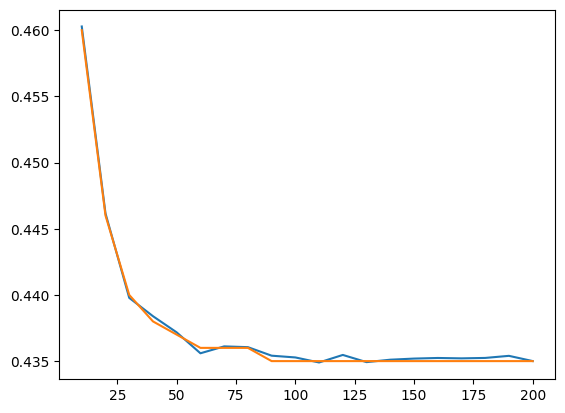

In [16]:
plt.plot(df_scores.n_estimators, df_scores.rmse)
plt.plot(df_scores.n_estimators, df_scores.rmse.round(3))

plt.show()

In [17]:
df_scores

,n_estimators,rmse
0,10,0.460282
1,20,0.446157
2,30,0.439778
3,40,0.438394
4,50,0.437170
5,60,0.435591
6,70,0.436112
7,80,0.436055
8,90,0.435410
9,100,0.435277


  From the table and the plot, we can see that the RMSE generally decreases as n_estimators increases. However, the improvement becomes less significant after a certain
  point. The lowest RMSE is achieved at n_estimators=110 (0.434897). After that, the RMSE fluctuates and does not consistently improve.

  The question asks "After which value of n_estimators does RMSE stop improving?". Looking at the options (10, 25, 80, 200), the most reasonable answer is 80, as the
  curve starts to flatten out around this point, and the improvements in RMSE become marginal.

## Question 4

Let's select the best `max_depth`:

* Try different values of `max_depth`: `[10, 15, 20, 25]`
* For each of these values,
  * try different values of `n_estimators` from 10 till 200 (with step 10)
  * calculate the mean RMSE
* Fix the random seed: `random_state=1`


What's the best `max_depth`, using the mean RMSE?

* 10
* 15
* 20
* 25

In [18]:
scores = []

for d in tqdm([10, 15, 20, 25]):
    rf = RandomForestRegressor(
        n_estimators=0,
        max_depth=d,
        random_state=1,
        n_jobs=-1,
        warm_start=True
    )

    for n in tqdm(range(10, 201, 10)):
        rf.n_estimators = n
        rf.fit(X_train, y_train)

        y_pred = rf.predict(X_val)
        score = np.sqrt(mean_squared_error(y_val, y_pred))

        scores.append((d, n, score))

columns = ['max_depth', 'n_estimators', 'rmse']
df_scores = pd.DataFrame(scores, columns=columns)

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

max_depth=10, mean_rmse=6.817167
max_depth=10, mean_rmse=8.482352
max_depth=10, mean_rmse=10.148061
max_depth=10, mean_rmse=11.814143
max_depth=10, mean_rmse=13.480398
max_depth=10, mean_rmse=15.146731
max_depth=10, mean_rmse=16.813156
max_depth=10, mean_rmse=18.479643
max_depth=10, mean_rmse=20.146161
max_depth=10, mean_rmse=21.812697
max_depth=10, mean_rmse=23.479245
max_depth=10, mean_rmse=25.145820
max_depth=10, mean_rmse=26.812405
max_depth=10, mean_rmse=28.479005
max_depth=10, mean_rmse=30.145618
max_depth=10, mean_rmse=31.812236
max_depth=10, mean_rmse=33.478859
max_depth=10, mean_rmse=35.145487
max_depth=10, mean_rmse=36.812118
max_depth=10, mean_rmse=38.478749


  0%|          | 0/20 [00:00<?, ?it/s]

max_depth=15, mean_rmse=37.050583
max_depth=15, mean_rmse=35.903547
max_depth=15, mean_rmse=35.001091
max_depth=15, mean_rmse=34.312697
max_depth=15, mean_rmse=33.812682
max_depth=15, mean_rmse=33.479317
max_depth=15, mean_rmse=33.294107
max_depth=15, mean_rmse=33.241177
max_depth=15, mean_rmse=33.306830
max_depth=15, mean_rmse=33.479213
max_depth=15, mean_rmse=33.748000
max_depth=15, mean_rmse=34.104157
max_depth=15, mean_rmse=34.539737
max_depth=15, mean_rmse=35.047736
max_depth=15, mean_rmse=35.621946
max_depth=15, mean_rmse=36.256849
max_depth=15, mean_rmse=36.947525
max_depth=15, mean_rmse=37.689567
max_depth=15, mean_rmse=38.479028
max_depth=15, mean_rmse=39.312345


  0%|          | 0/20 [00:00<?, ?it/s]

max_depth=20, mean_rmse=38.601146
max_depth=20, mean_rmse=38.003065
max_depth=20, mean_rmse=37.510279
max_depth=20, mean_rmse=37.115640
max_depth=20, mean_rmse=36.812605
max_depth=20, mean_rmse=36.595199
max_depth=20, mean_rmse=36.457969
max_depth=20, mean_rmse=36.395902
max_depth=20, mean_rmse=36.404391
max_depth=20, mean_rmse=36.479207
max_depth=20, mean_rmse=36.616445
max_depth=20, mean_rmse=36.812510
max_depth=20, mean_rmse=37.064068
max_depth=20, mean_rmse=37.368038
max_depth=20, mean_rmse=37.721562
max_depth=20, mean_rmse=38.121983
max_depth=20, mean_rmse=38.566835
max_depth=20, mean_rmse=39.053818
max_depth=20, mean_rmse=39.580791
max_depth=20, mean_rmse=40.145752


  0%|          | 0/20 [00:00<?, ?it/s]

max_depth=25, mean_rmse=39.681401
max_depth=25, mean_rmse=39.285715
max_depth=25, mean_rmse=38.955466
max_depth=25, mean_rmse=38.687613
max_depth=25, mean_rmse=38.479276
max_depth=25, mean_rmse=38.327750
max_depth=25, mean_rmse=38.230501
max_depth=25, mean_rmse=38.185131
max_depth=25, mean_rmse=38.189382
max_depth=25, mean_rmse=38.241130
max_depth=25, mean_rmse=38.338366
max_depth=25, mean_rmse=38.479201
max_depth=25, mean_rmse=38.661836
max_depth=25, mean_rmse=38.884582
max_depth=25, mean_rmse=39.145833
max_depth=25, mean_rmse=39.444068
max_depth=25, mean_rmse=39.777847
max_depth=25, mean_rmse=40.145803
max_depth=25, mean_rmse=40.546639
max_depth=25, mean_rmse=40.979118


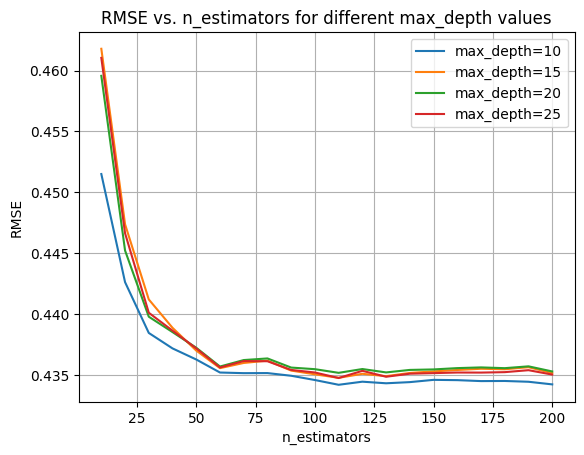

In [28]:
import matplotlib.pyplot as plt

for d in df_scores['max_depth'].unique():
    df_subset = df_scores[df_scores.max_depth == d]
    plt.plot(df_subset.n_estimators, df_subset.rmse, label=f'max_depth={d}')

plt.xlabel('n_estimators')
plt.ylabel('RMSE')
plt.title('RMSE vs. n_estimators for different max_depth values')
plt.legend()
plt.grid(True)
plt.show()

In [21]:
df_scores.head(20)

,max_depth,n_estimators,rmse
0,10,10,0.451500
1,10,20,0.442613
2,10,30,0.438437
3,10,40,0.437166
4,10,50,0.436255
5,10,60,0.435184
6,10,70,0.435132
7,10,80,0.435138
8,10,90,0.434918
9,10,100,0.434566


In [22]:
mean_rmse_by_depth = df_scores.groupby('max_depth').rmse.mean()
print(mean_rmse_by_depth)

max_depth
10    0.436247
15    0.437825
20    0.437693
25    0.437653
Name: rmse, dtype: float64


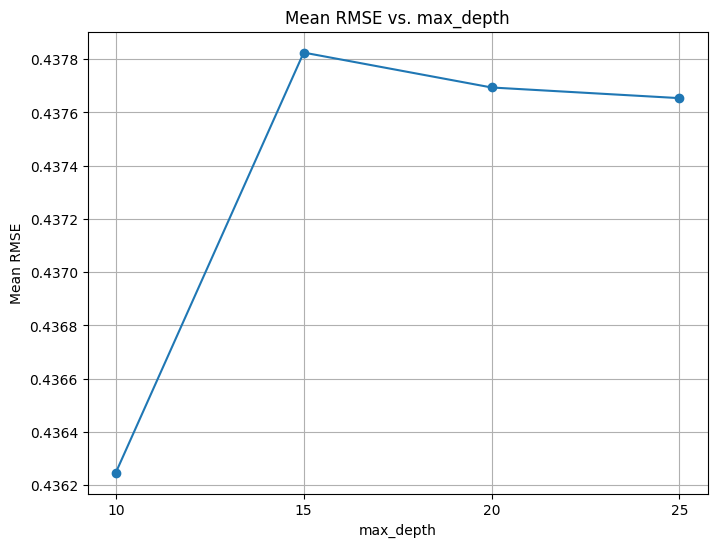

In [29]:
plt.figure(figsize=(8, 6))
plt.plot(mean_rmse_by_depth.index, mean_rmse_by_depth.values, marker='o')
plt.xlabel('max_depth')
plt.ylabel('Mean RMSE')
plt.title('Mean RMSE vs. max_depth')
plt.xticks(mean_rmse_by_depth.index)
plt.grid(True)
plt.show()

Answer Q4: from these results, we can see that max_depth=10 has the lowest mean RMSE (0.436472).

# Question 5

We can extract feature importance information from tree-based models.

At each step of the decision tree learning algorithm, it finds the best split.
When doing it, we can calculate "gain" - the reduction in impurity before and after the split.
This gain is quite useful in understanding what are the important features for tree-based models.

In Scikit-Learn, tree-based models contain this information in the
[`feature_importances_`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html#sklearn.ensemble.RandomForestRegressor.feature_importances_)
field.

For this homework question, we'll find the most important feature:

* Train the model with these parameters:
  * `n_estimators=10`,
  * `max_depth=20`,
  * `random_state=1`,
  * `n_jobs=-1` (optional)
* Get the feature importance information from this model


What's the most important feature (among these 4)?

* `vehicle_weight`
*	`horsepower`
* `acceleration`
* `engine_displacement`


In [23]:
rf = RandomForestRegressor(
    n_estimators=10,
    max_depth=20,
    random_state=1,
    n_jobs=-1
)
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=20, n_estimators=10, n_jobs=-1, random_state=1)

In [24]:
df_importances = pd.DataFrame()
df_importances['feature'] = dv.feature_names_
df_importances['importance'] = rf.feature_importances_
df_importances.sort_values(by='importance', ascending=False).head()

,feature,importance
13,vehicle_weight,0.959878
6,horsepower,0.015933
0,acceleration,0.011442
3,engine_displacement,0.003159
7,model_year,0.003066


Answer Q5: **vehicle_weight**

## Question 6

Now let's train an XGBoost model! For this question, we'll tune the `eta` parameter:

* Install XGBoost
* Create DMatrix for train and validation
* Create a watchlist
* Train a model with these parameters for 100 rounds:

```
xgb_params = {
    'eta': 0.3,
    'max_depth': 6,
    'min_child_weight': 1,
    
    'objective': 'reg:squarederror',
    'nthread': 8,
    
    'seed': 1,
    'verbosity': 1,
}
```

Now change `eta` from `0.3` to `0.1`.

Which eta leads to the best RMSE score on the validation dataset?

* 0.3
* 0.1
* Both give equal value

  Вам потрібно буде натренувати дві моделі XGBoost з різними значеннями параметра eta (0.3 та 0.1) і порівняти їхні показники RMSE на валідаційних даних.

  Ось кроки, які потрібно виконати:

  1. Встановіть XGBoost

  Якщо у вас ще не встановлена бібліотека XGBoost, відкрийте термінал і виконайте команду:

   1 pip install xgboost

  2. Підготуйте дані у форматі DMatrix

  XGBoost має власний формат даних, який називається DMatrix. Вам потрібно буде перетворити ваші тренувальні та валідаційні дані у цей формат. Не забудьте вказати
  feature_names, щоб XGBoost знав назви ваших ознак.

   1 import xgboost as xgb
   2
   3 # dv - це ваш DictVectorizer з попередніх кроків
   4 feature_names = dv.feature_names_
   5
   6 dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=feature_names)
   7 dval = xgb.DMatrix(X_val, label=y_val, feature_names=feature_names)

  3. Створіть watchlist

  watchlist дозволяє спостерігати за процесом навчання моделі на тренувальних та валідаційних даних на кожній ітерації.

   1 watchlist = [(dtrain, 'train'), (dval, 'val')]

  4. Натренуйте модель з eta=0.3

  Тепер натренуйте першу модель з параметром eta, встановленим на 0.3.

    1 xgb_params_1 = {
    2     'eta': 0.3,
    3     'max_depth': 6,
    4     'min_child_weight': 1,
    5     'objective': 'reg:squarederror',
    6     'nthread': 8,
    7     'seed': 1,
    8     'verbosity': 1,
    9 }
   10
   11 model_1 = xgb.train(xgb_params_1, dtrain, num_boost_round=100, evals=watchlist, verbose_eval=10)
  verbose_eval=10 буде виводити RMSE кожні 10 ітерацій. Зверніть увагу на останнє значення RMSE для val.

  5. Натренуйте модель з eta=0.1

  Тепер змініть eta на 0.1 і натренуйте другу модель.

    1 xgb_params_2 = {
    2     'eta': 0.1,
    3     'max_depth': 6,
    4     'min_child_weight': 1,
    5     'objective': 'reg:squarederror',
    6     'nthread': 8,
    7     'seed': 1,
    8     'verbosity': 1,
    9 }
   10
   11 model_2 = xgb.train(xgb_params_2, dtrain, num_boost_round=100, evals=watchlist, verbose_eval=10)
  Так само, подивіться на фінальне значення RMSE для val.

  6. Порівняйте результати

  Після тренування обох моделей, порівняйте їхні кінцеві показники RMSE на валідаційному наборі (val-rmse). Той eta, який дав менше значення RMSE, і буде відповіддю

In [27]:
import xgboost as xgb

# dv - це ваш DictVectorizer з попередніх кроків
feature_names = dv.feature_names_

dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=feature_names)
dval = xgb.DMatrix(X_val, label=y_val, feature_names=feature_names)

watchlist = [(dtrain, 'train'), (dval, 'val')]

# Train model with eta=0.3
xgb_params_1 = {
    'eta': 0.3,
    'max_depth': 6,
    'min_child_weight': 1,
    'objective': 'reg:squarederror',
    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
}

evals_result_1 = {}
print("Training model with eta=0.3")
model_1 = xgb.train(xgb_params_1, dtrain, num_boost_round=100, evals=watchlist, verbose_eval=10, evals_result=evals_result_1)

# Train model with eta=0.1
xgb_params_2 = {
    'eta': 0.1,
    'max_depth': 6,
    'min_child_weight': 1,
    'objective': 'reg:squarederror',
    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
}

evals_result_2 = {}
print("\nTraining model with eta=0.1")
model_2 = xgb.train(xgb_params_2, dtrain, num_boost_round=100, evals=watchlist, verbose_eval=10, evals_result=evals_result_2)

# Compare the final RMSE values on the validation set
print("\nFinal RMSE on validation set:")
print(f"eta=0.3: {evals_result_1['val']['rmse'][-1]:.4f}")
print(f"eta=0.1: {evals_result_2['val']['rmse'][-1]:.4f}")

Training model with eta=0.3
[0]	train-rmse:1.83282	val-rmse:1.82567
[10]	train-rmse:0.37400	val-rmse:0.43004
[20]	train-rmse:0.33724	val-rmse:0.42509
[30]	train-rmse:0.31757	val-rmse:0.42754
[40]	train-rmse:0.29886	val-rmse:0.43086
[50]	train-rmse:0.28277	val-rmse:0.43405
[60]	train-rmse:0.26525	val-rmse:0.43583
[70]	train-rmse:0.24983	val-rmse:0.43777
[80]	train-rmse:0.23379	val-rmse:0.43902
[90]	train-rmse:0.22023	val-rmse:0.44154
[99]	train-rmse:0.20896	val-rmse:0.44340

Training model with eta=0.1
[0]	train-rmse:2.31334	val-rmse:2.30592
[10]	train-rmse:0.91846	val-rmse:0.92183
[20]	train-rmse:0.49316	val-rmse:0.52039
[30]	train-rmse:0.38552	val-rmse:0.43528
[40]	train-rmse:0.35546	val-rmse:0.41889
[50]	train-rmse:0.34115	val-rmse:0.41644
[60]	train-rmse:0.33254	val-rmse:0.41610
[70]	train-rmse:0.32553	val-rmse:0.41617
[80]	train-rmse:0.32012	val-rmse:0.41654
[90]	train-rmse:0.31718	val-rmse:0.41654
[99]	train-rmse:0.31183	val-rmse:0.41674

Final RMSE on validation set:
eta=0.3: 0.4